In [1]:
from pathlib import Path
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/motion_CNN
    data_path = Path("/content/drive/MyDrive/NUIN/van_hateren/") 
    !git pull
else: 
    data_path = Path("/home/guardomayas/NUIN/van_hateren/vanhateren_iml")


In [2]:
import numpy as np

In [ ]:
from motionnet.dataset.van_hateren_utils import log_image

In [19]:
import os
from pathlib import Path

import numpy as np
import torch
from scipy.ndimage import map_coordinates, spline_filter, zoom
from torch.utils.data import Dataset

VH_SHAPE = (1024, 1536)


class GetNaturalMovies(Dataset):
    def __init__(
        self,
        data_path,
        batch_idx=0,
        batch_size=5,
        log_image=True,
        normalize_images=True,
        crop_hw=(250, 250),
        downsample_hw=None,          # None = no resize
        frames_per_segment=75,
        fps=75,
        gray_sec=0.2,
        gray_value=0.0,              # 0.0 pairs with z-scored images
        samples_per_image=6,
        vel_half_life_s=0.2,
        vel_std=(300.0, 300.0),      # px/s in source pixels
        vel_corr=0.0,
        start_jitter=0.0,
        seed=20260818,
        movie_format="TCHW",
        dtype=torch.float32,
    ):
        self.data_path = data_path
        self.batch_idx = batch_idx
        self.batch_size = batch_size
        self.log_image = log_image
        self.normalize_images = normalize_images
        self.crop_hw = tuple(crop_hw)
        self.downsample_hw = downsample_hw
        self.T = int(frames_per_segment)
        self.fps = float(fps)
        self.gray_frames = int(round(gray_sec * fps))
        self.gray_value = float(gray_value)
        self.samples_per_image = int(samples_per_image)
        self.tau = vel_half_life_s / np.log(2)
        self.vel_std = ((float(vel_std),) * 2 if np.isscalar(vel_std)
                        else tuple(map(float, vel_std)))
        self.vel_corr = float(vel_corr)
        self.start_jitter = float(start_jitter)
        self.seed = int(seed)
        self.movie_format = movie_format
        self.dtype = dtype

        self.batch_imgs, self.names = self._load_batch()
        self.n_imgs, self.H, self.W = self.batch_imgs.shape

        ch, cw = self.crop_hw
        self.lim_y = (self.H - ch) / 2 - self.start_jitter
        self.lim_x = (self.W - cw) / 2 - self.start_jitter
        if min(self.lim_x, self.lim_y) <= 0:
            raise ValueError("crop_hw + start_jitter exceeds image bounds")

        # Spline coefficients once per image; map_coordinates then skips
        # prefiltering on every frame.
        self._coeffs = np.stack(
            [spline_filter(im, order=3, output=np.float32)
             for im in self.batch_imgs]
        )

        ay = np.arange(ch) - (ch - 1) / 2
        ax = np.arange(cw) - (cw - 1) / 2
        self._gy, self._gx = np.meshgrid(ay, ax, indexing="ij")

        self.scale = 1.0 if downsample_hw is None else downsample_hw[0] / ch

    # ------------------------------------------------------------------
    # Images
    # ------------------------------------------------------------------
    def _load_batch(self, dtype=np.float32):
        path = Path(self.data_path)
        iml_files = sorted(path.glob("*.iml"))
        start = self.batch_idx * self.batch_size
        batch_files = iml_files[start:start + self.batch_size]
        if not batch_files:
            raise FileNotFoundError(f"no .iml files for batch {self.batch_idx}")
        print(f"Found {len(iml_files)} .iml in {path}; "
              f"loading batch {self.batch_idx} ({len(batch_files)} images).")

        imgs, names = [], []
        for fname in batch_files:
            raw = np.fromfile(fname, dtype=">u2").reshape(VH_SHAPE)
            names.append(os.path.basename(fname))
            img = raw.astype(dtype)
            if self.log_image:
                img = np.log1p(img)          # safe at raw == 0
            if self.normalize_images:
                img = (img - img.mean()) / (img.std() + 1e-8)
            imgs.append(img)

        return np.stack(imgs), names

    # ------------------------------------------------------------------
    # Velocity
    # ------------------------------------------------------------------
    @staticmethod
    def _reflect(x, lim):
        p = 4.0 * lim
        y = np.mod(x + lim, p)
        y = np.where(y > 2 * lim, p - y, y)
        return y - lim

    def generate_velocity_trace_2d(self, rng):
        """Stationary 2D OU velocity; position reflected to stay in bounds."""
        dt = 1.0 / self.fps
        alpha = np.exp(-dt / self.tau)
        sx, sy = self.vel_std
        r = self.vel_corr
        if not -1.0 <= r <= 1.0:
            raise ValueError("vel_corr must be in [-1, 1]")
        cov = np.array([[sx**2, r * sx * sy], [r * sx * sy, sy**2]])

        noise = rng.multivariate_normal(np.zeros(2), cov, size=self.T)
        vel = np.empty((self.T, 2))
        vel[0] = rng.multivariate_normal(np.zeros(2), cov)   # stationary start
        b = np.sqrt(1 - alpha**2)
        for t in range(1, self.T):
            vel[t] = alpha * vel[t - 1] + b * noise[t]

        pos = np.cumsum(vel, axis=0) * dt
        pos -= pos[0]
        pos[:, 0] = self._reflect(pos[:, 0], self.lim_x)
        pos[:, 1] = self._reflect(pos[:, 1], self.lim_y)

        # Recompute velocity from the reflected trace so labels match pixels.
        vel = np.zeros_like(pos)
        vel[1:] = np.diff(pos, axis=0) * self.fps
        vel[0] = vel[1]
        return vel.astype(np.float32), pos.astype(np.float32)

    # ------------------------------------------------------------------
    # Rendering
    # ------------------------------------------------------------------
    def render_movie(self, img_idx, cx, cy, pos):
        ch, cw = self.crop_hw
        out = np.empty((self.T, ch, cw), dtype=np.float32)
        coeffs = self._coeffs[img_idx]
        for t in range(self.T):
            dx, dy = pos[t]
            out[t] = map_coordinates(
                coeffs,
                [self._gy + cy + dy, self._gx + cx + dx],
                order=3, mode="reflect", prefilter=False,
            )
        return out

    def add_gray_padding(self, movie):
        gray = np.full((self.gray_frames, *movie.shape[1:]),
                       self.gray_value, dtype=movie.dtype)
        return np.concatenate([gray, movie], axis=0)

    def pad_position_trace(self, pos):
        return np.concatenate([np.repeat(pos[:1], self.gray_frames, 0), pos])

    def pad_velocity_trace(self, vel):
        pre = np.zeros((self.gray_frames, vel.shape[1]), dtype=vel.dtype)
        return np.concatenate([pre, vel])

    # ------------------------------------------------------------------
    # Dataset interface
    # ------------------------------------------------------------------
    def __len__(self):
        return self.n_imgs * self.samples_per_image

    def __getitem__(self, idx):
        img_idx, rep = divmod(idx, self.samples_per_image)
        global_idx = self.batch_idx * self.batch_size + img_idx
        rng = np.random.default_rng((self.seed, global_idx, rep))

        vel, pos = self.generate_velocity_trace_2d(rng)

        cx = self.W / 2 + rng.uniform(-self.start_jitter, self.start_jitter)
        cy = self.H / 2 + rng.uniform(-self.start_jitter, self.start_jitter)

        movie = self.render_movie(img_idx, cx, cy, pos)

        if self.downsample_hw is not None:
            movie = zoom(movie, (1, self.scale, self.scale),
                         order=1, prefilter=True).astype(np.float32)

        movie = self.add_gray_padding(movie)
        pos = self.pad_position_trace(pos)
        vel = self.pad_velocity_trace(vel)

        if self.movie_format == "TCHW":
            movie = movie[:, None, :, :]
        elif self.movie_format == "THW":
            pass
        else:
            raise ValueError(f"Unknown movie_format: {self.movie_format}")

        return {
            "movie": torch.from_numpy(movie).to(self.dtype),
            "pos_px": torch.from_numpy(pos).to(self.dtype),
            "vel_px_s": torch.from_numpy(vel).to(self.dtype),
            "vel_input_px_frame": torch.from_numpy(
                vel * self.scale / self.fps).to(self.dtype),
            "image_idx": global_idx,
            "name": self.names[img_idx],
        }
dataset = GetNaturalMovies(data_path, downsample_hw=(50,50), crop_hw=(250, 250), start_jitter=20)
s = dataset[0]
print(s["movie"].shape, s["vel_px_s"].std(0))
# frame-difference energy should track |v|

Found 4167 .iml in /home/guardomayas/NUIN/van_hateren/vanhateren_iml; loading batch 0 (5 images).
torch.Size([90, 1, 50, 50]) tensor([191.3923, 236.4143])


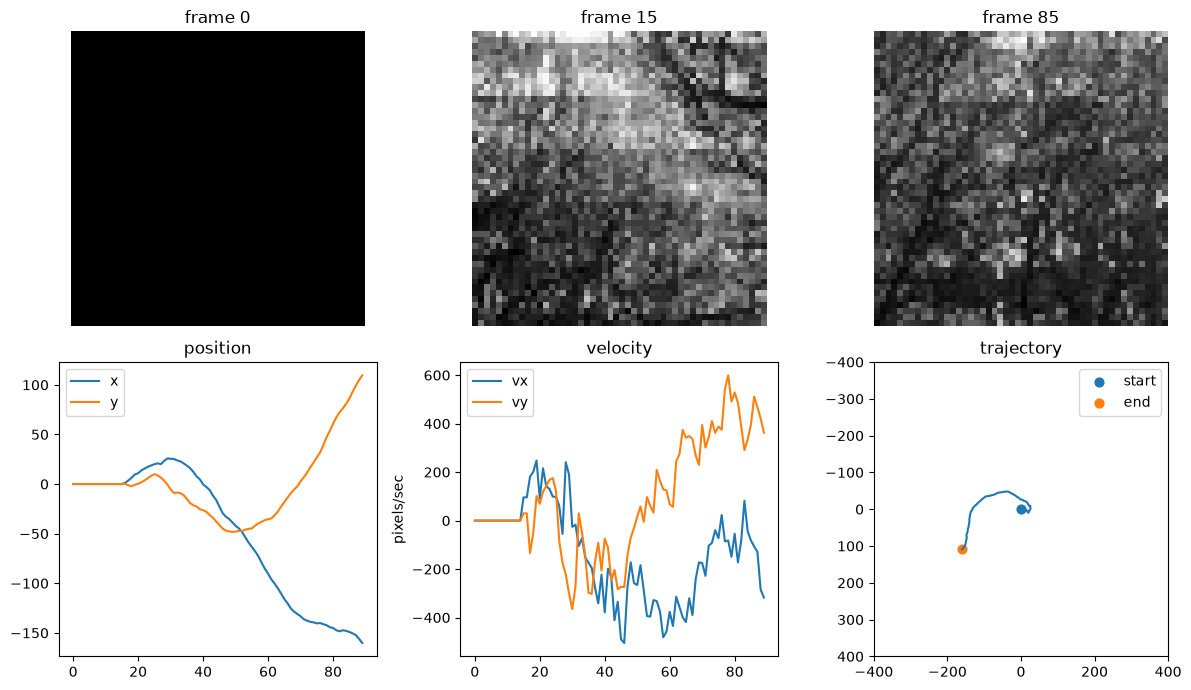

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation


def show_batch_frames(batch, n_samples=4, frame_indices=None):
    """
    Show selected frames from several samples in the batch.

    batch["movie"]: (B, T, 1, H, W)
    """
    movies = batch["movie"]
    B, T, C, H, W = movies.shape

    n_samples = min(n_samples, B)

    if frame_indices is None:
        frame_indices = [0, min(14, T-1), min(T//2, T-1), T-1]
    else: 
        print("Using provided frame_indices:", frame_indices)
    n_rows = n_samples
    n_cols = len(frame_indices)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n_samples):
        for j, t in enumerate(frame_indices):
            ax = axes[i, j]
            frame = movies[i, t, 0].detach().cpu().numpy()
            ax.imshow(frame, cmap="gray", vmin=0, vmax=1)
            ax.set_title(f"Sample {i}, frame={t}")
            ax.axis("off")

    plt.tight_layout()
    plt.show()
    

def show_one_sample_summary(dataset, sample_idx=0, frame_indices=None):
    """
    Visualize one sample:
    - first/mid/last movie frames
    - x,y position
    - vx,vy velocity
    """
    sample = dataset[sample_idx]
    movie = sample["movie"].detach().cpu().numpy()   # (T, 1, H, W) if TCHW
    pos = sample["pos_px"].detach().cpu().numpy()       # (T, 2)
    vel = sample["vel_px_s"].detach().cpu().numpy()       # (T, 2)

    T = movie.shape[0]
    if frame_indices is None:
        frame_indices = [0, min(T//2, T-1), T-1]

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))

    # frames
    for j, t in enumerate(frame_indices):
        axes[0, j].imshow(movie[t, 0], cmap="gray")
        axes[0, j].set_title(f"frame {t}")
        axes[0, j].axis("off")

    # position trace
    axes[1, 0].plot(pos[:, 0], label="x")
    axes[1, 0].plot(pos[:, 1], label="y")
    # axes[1, 0].invert_yaxis()  # invert y to match traj coordinates
    axes[1, 0].set_title("position")
    axes[1, 0].legend()
    # axes[1, 0].grid(True, alpha=0.3)

    # velocity trace
    axes[1, 1].plot(vel[:, 0], label="vx")
    axes[1, 1].plot(vel[:, 1], label="vy")
    axes[1, 1].set_title("velocity")
    axes[1,1].set_ylabel("pixels/sec")
    axes[1, 1].legend()
    # axes[1, 1].grid(True, alpha=0.3)

    # xy trajector
    axes[1, 2].plot(pos[:, 0], pos[:, 1], lw=1.5)
    axes[1, 2].scatter(pos[0, 0], pos[0, 1], label="start", s=40)
    axes[1, 2].scatter(pos[-1, 0], pos[-1, 1], label="end", s=40)
    axes[1, 2].set_title("trajectory")
    axes[1, 2].set_aspect("equal")
    axes[1, 2].legend()
    # axes[1, 2].grid(True, alpha=0.3)
    
    axes[1,2].set_xlim(-400, 400)
    axes[1,2].set_ylim(-400, 400)
    axes[1, 2].invert_yaxis()  # invert y to match traj coordinates

    plt.tight_layout()
    plt.show()
    
show_one_sample_summary(dataset, 0, frame_indices=[0,15,85])